In [ ]:
!pip install -q transformers torch pandas numpy nltk tqdm python-dateutil datasets scikit-learn matplotlib

In [ ]:
import os, re, glob, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from dateutil.parser import parse as parse_date

import nltk
nltk.download("punkt", quiet=True)
from nltk.tokenize import sent_tokenize

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
CSV_INPUT_PATH = "bsp_speech_dataset.csv"
TXT_FOLDER = "speeches_txt"

# Column names
COL_SPEECH_ID = "speech_id"
COL_DATE      = "Date"
COL_TITLE     = "Title"
COL_TEXT      = "Text"

# FinBERT model for sentiment
FINBERT_MODEL = "ProsusAI/finbert"  # outputs [neg, neu, pos]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN = 512
BATCH_SIZE = 16

# Output files (Part A)
OUT_SENTENCES_CSV = "bsp_sentences_scored.csv"
OUT_SPEECHES_CSV  = "bsp_speeches_agg.csv"

In [ ]:
import pandas as pd

df = pd.read_csv(CSV_INPUT_PATH)
print(df.columns)

Index(['index', 'Title', 'Date', 'Location', 'Occasion', 'Speaker', 'Text',
       'Len', 'Link', 'last_name', 'year'],
      dtype='object')


In [ ]:
def basic_clean(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text

def try_parse_date(s: str):
    try:
        return parse_date(str(s)).date().isoformat()
    except Exception:
        return None

def infer_date_from_filename(fname: str):
    m = re.search(r"(20\d{2})[-_](\d{2})[-_](\d{2})", fname)
    if m:
        return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
    return None

def sentence_split_document(doc_text: str) -> list:
    sents = [s.strip() for s in sent_tokenize(doc_text)]
    sents = [s for s in sents if len(s.split()) >= 3]  # drop ultra-short
    return sents

def wavg(group, col, weight_col="tok_len"):
    w = group[weight_col].fillna(1).clip(lower=1)
    return np.average(group[col], weights=w)

In [ ]:
def load_speeches_from_csv(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        "index": "speech_id", # Use "index" as speech_id
        COL_DATE: "date",
        COL_TITLE: "title",
        COL_TEXT: "text"
    })
    if "title" not in df.columns: df["title"] = None
    if "date" in df.columns:
        df["date"] = df["date"].map(try_parse_date)
    else:
        df["date"] = None
    df["text"] = df["text"].map(basic_clean)
    return df[["speech_id","date","title","text"]] # Correct column names in return statement

def load_speeches_from_txt_folder(folder):
    rows = []
    for p in glob.glob(os.path.join(folder, "*.txt")):
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            raw = f.read()
        speech_id = os.path.splitext(os.path.basename(p))[0]
        date = infer_date_from_filename(speech_id)
        rows.append({
            "speech_id": speech_id,
            "date": date,
            "title": None,
            "text": basic_clean(raw)
        })
    return pd.DataFrame(rows)

if CSV_INPUT_PATH:
    speeches = load_speeches_from_csv(CSV_INPUT_PATH)
else:
    speeches = load_speeches_from_txt_folder(TXT_FOLDER)

assert len(speeches) > 0, "No speeches found. Provide a CSV or put .txt files in the folder."

speeches.head()

,speech_id,date,title,text
0,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,"The Manila Times President and CEO, Mr. Dante ..."
1,1,2020-02-28,Finding Opportunities in a Borderless World,To the officers and members of the Fund Manage...
2,2,2020-02-27,Gearing up for the Road Ahead: With Foresight ...,Officers and members of the Professional Insur...
3,3,2020-02-06,A Strong Nation Amid A Slowing and Volatile World,Officers and members of the Management Associa...
4,4,2020-01-31,Welcome Dinner Remarks,"Governor Perry, Deputy Governors, colleagues f..."


In [ ]:
nltk.download('punkt_tab', quiet=True)

True

In [ ]:
sent_rows = []
for _, row in tqdm(speeches.iterrows(), total=len(speeches), desc="Sentence splitting"):
    for i, s in enumerate(sentence_split_document(row["text"])):
        sent_rows.append({
            "speech_id": row["speech_id"],
            "date": row["date"],
            "title": row["title"],
            "sentence_ix": i,
            "text": s
        })
df_sent = pd.DataFrame(sent_rows)
assert len(df_sent) > 0, "No sentences after splitting."
df_sent.head()


Sentence splitting: 100%|██████████| 676/676 [00:01<00:00, 486.93it/s]


,speech_id,date,title,sentence_ix,text
0,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,0,"The Manila Times President and CEO, Mr. Dante ..."
1,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,1,It is a pleasure to be joining today's Busines...
2,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,2,In line with the conference theme and given th...
3,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,3,High and volatile inflation is undesirable bec...
4,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,4,"Until recently, the Philippines is characteriz..."


In [ ]:
tok_s = AutoTokenizer.from_pretrained(FINBERT_MODEL)
mdl_s = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL).to(DEVICE)
mdl_s.eval()

def score_batch_finbert(texts):
    enc = tok_s(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = mdl_s(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()  # [neg, neu, pos]
    return probs

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
neg, neu, pos, tok_len = [], [], [], []

for i in tqdm(range(0, len(df_sent), BATCH_SIZE), desc="FinBERT scoring"):
    batch = df_sent.iloc[i:i+BATCH_SIZE]
    texts = batch["text"].tolist()
    probs = score_batch_finbert(texts)
    neg.extend(probs[:,0]); neu.extend(probs[:,1]); pos.extend(probs[:,2])
    # approx token length as weight
    tlen = [len(tok_s(t, truncation=True, max_length=MAX_LEN)["input_ids"]) for t in texts]
    tok_len.extend(tlen)

df_sent["p_neg"] = neg # Renamed for consistency
df_sent["p_neu"] = neu # Renamed for consistency
df_sent["p_pos"] = pos # Renamed for consistency
df_sent["tok_len"] = tok_len
df_sent["tone"] = df_sent["p_pos"] - df_sent["p_neg"] # Renamed sent_score to tone

df_sent.head()

FinBERT scoring: 100%|██████████| 2698/2698 [02:33<00:00, 17.62it/s]


,speech_id,date,title,sentence_ix,text,neg,neu,pos,tok_len,sent_score,p_neg,p_neu,p_pos,tone
0,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,0,"The Manila Times President and CEO, Mr. Dante ...",0.572503,0.013560,0.413936,46,-0.158567,0.572503,0.013560,0.413936,-0.158567
1,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,1,It is a pleasure to be joining today's Busines...,0.621318,0.012620,0.366063,50,-0.255255,0.621318,0.012620,0.366063,-0.255255
2,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,2,In line with the conference theme and given th...,0.166416,0.011002,0.822582,42,0.656166,0.166416,0.011002,0.822582,0.656166
3,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,3,High and volatile inflation is undesirable bec...,0.009170,0.957199,0.033631,32,0.024462,0.009170,0.957199,0.033631,0.024462
4,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,4,"Until recently, the Philippines is characteriz...",0.022352,0.871985,0.105663,16,0.083310,0.022352,0.871985,0.105663,0.083310


In [ ]:
def share_over(x, thr=0.5): return (x > thr).mean()
def majority_label(x): return x.value_counts().idxmax() if len(x) else "neutral"

agg = df_sent.groupby(["speech_id","date","title"]).apply(
    lambda g: pd.Series({
        "tone_mean": wavg(g, "tone", weight_col="tok_len"),
        "tone_median": g["tone"].median(),
        "pos_share": share_over(g["p_pos"]),
        "neg_share": share_over(g["p_neg"]),
        "neu_share": share_over(g["p_neu"]),
        "n_sent": len(g),
    })
).reset_index()

# Infer label from probabilities for majority label calculation
df_sent["label"] = ["negative" if row["p_neg"] > row["p_pos"] and row["p_neg"] > row["p_neu"] else "positive" if row["p_pos"] > row["p_neg"] and row["p_pos"] > row["p_neu"] else "neutral" for _, row in df_sent[["p_neg", "p_neu", "p_pos"]].iterrows()]


maj = (df_sent
       .groupby(["speech_id","date","title"])["label"]
       .apply(majority_label)
       .reset_index(name="label_majority"))


speech_agg = agg.merge(maj, on=["speech_id","date","title"], how="left") # Renamed to speech_agg for consistency with previous cell

speech_agg.head()

/tmp/ipython-input-3351016876.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = df_sent.groupby(["speech_id","date","title"]).apply(


,speech_id,date,title,tone_mean,tone_median,pos_share,neg_share,neu_share,n_sent,label_majority
0,0,2020-03-03,Staying on Track in 2020: Sustaining Positive ...,-0.361760,-0.391816,0.208333,0.562500,0.208333,96.0,negative
1,1,2020-02-28,Finding Opportunities in a Borderless World,-0.121493,-0.143407,0.432000,0.512000,0.048000,125.0,negative
2,2,2020-02-27,Gearing up for the Road Ahead: With Foresight ...,-0.303988,-0.485688,0.234375,0.585938,0.164062,128.0,negative
3,3,2020-02-06,A Strong Nation Amid A Slowing and Volatile World,-0.311125,-0.436914,0.252874,0.574713,0.149425,87.0,negative
4,4,2020-01-31,Welcome Dinner Remarks,0.397506,0.447694,0.684211,0.263158,0.052632,19.0,positive


In [ ]:
speech_agg.to_csv(OUT_SPEECHES_CSV, index=False)
df_sent.to_csv(OUT_SENTENCES_CSV, index=False)

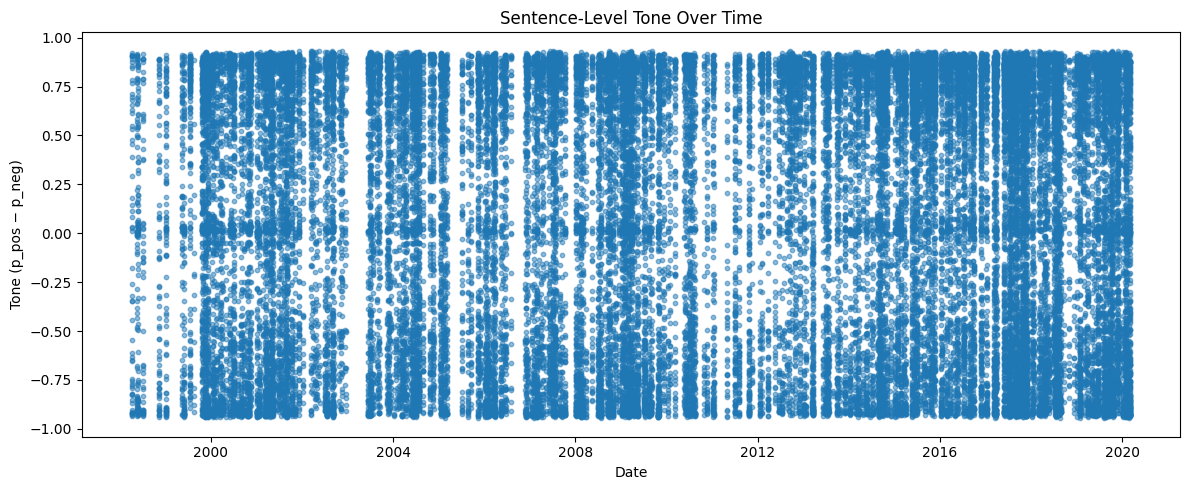

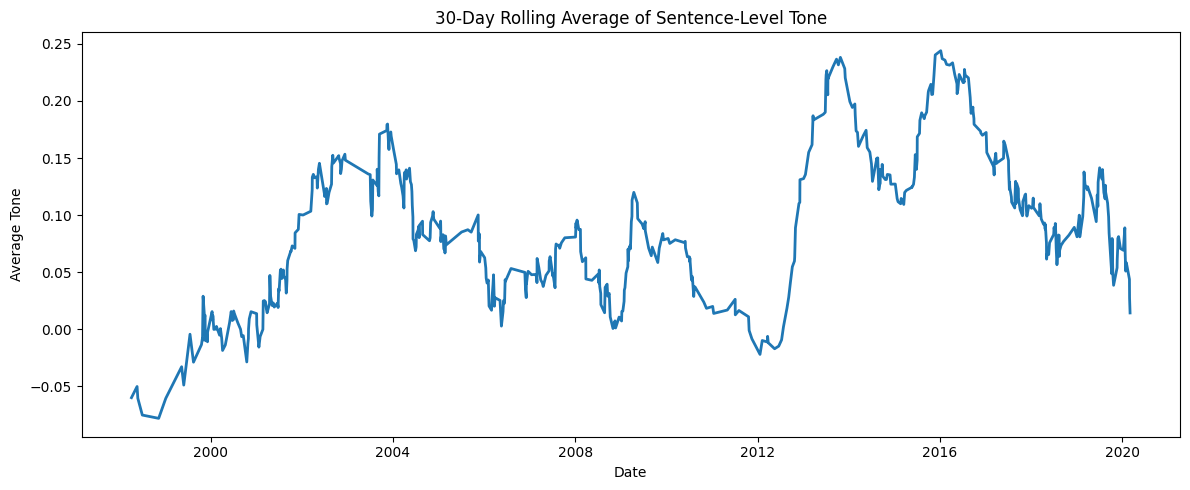

In [ ]:
## VISUALIZATION
import matplotlib.pyplot as plt

df_sent['date'] = pd.to_datetime(df_sent['date'], errors="coerce")

plt.figure(figsize=(12,5))
plt.scatter(df_sent['date'], df_sent["tone"], s=10, alpha=0.5)
plt.title("Sentence-Level Tone Over Time")
plt.xlabel("Date"); plt.ylabel("Tone (p_pos − p_neg)")
plt.tight_layout(); plt.show()

daily_mean = df_sent.groupby('date')["tone"].mean().rolling(30, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(daily_mean.index, daily_mean.values, linewidth=2)
plt.title("30-Day Rolling Average of Sentence-Level Tone")
plt.xlabel("Date"); plt.ylabel("Average Tone")
plt.tight_layout(); plt.show()